In [18]:
import numpy as np
import matplotlib.pyplot as plt
import openmc

from numpy.polynomial.legendre import legval2d

uo2 = openmc.Material(name='UO2')
uo2.set_density('g/cm3', 10.5)
uo2.add_nuclide('U235', 0.04, 'wo')
uo2.add_nuclide('U238', 0.84, 'wo')
uo2.add_nuclide('O16',  0.12, 'wo')

b4c = openmc.Material(name='B4C')
b4c.set_density('g/cm3', 2.52)
b4c.add_nuclide('B10',  0.144, 'wo')
b4c.add_nuclide('B11',  0.636, 'wo')
b4c.add_nuclide('C12',  0.22,  'wo')

materials = openmc.Materials([uo2, b4c])

slab_widths = [5.0, 3.0, 5.0, 3.0, 5.0]   # cm
slab_fills  = [uo2, b4c, uo2, b4c, uo2]
x_total     = sum(slab_widths)              # 17 cm

planes = [openmc.XPlane(0.0, boundary_type='reflective')]
x = 0.0
for w in slab_widths:
    x += w
    planes.append(openmc.XPlane(x))
planes[-1].boundary_type = 'reflective'

y_min = openmc.YPlane(-1.0, boundary_type='reflective')
y_max = openmc.YPlane( 1.0, boundary_type='reflective')
z_min = openmc.ZPlane(-1.0, boundary_type='reflective')
z_max = openmc.ZPlane( 1.0, boundary_type='reflective')
yz_region = +y_min & -y_max & +z_min & -z_max

cells = [openmc.Cell(fill=mat, region=+planes[i] & -planes[i+1] & yz_region, name=mat.name) for i, mat in enumerate(slab_fills)]

geometry = openmc.Geometry(openmc.Universe(cells=cells))

settings = openmc.Settings()
settings.run_mode  = 'eigenvalue'
settings.batches   = 300
settings.inactive  = 100
settings.particles = 100000
settings.source    = openmc.IndependentSource(space=openmc.stats.Box([0.0, -1.0, -1.0], [x_total, 1.0, 1.0]))

slab_tallies = []

order = order_x = order_y = 3

for i, (mat, x_lo, x_hi) in enumerate(
        zip(slab_fills,
            [p.x0 for p in planes[:-1]],
            [p.x0 for p in planes[1:]])):

    filt = openmc.SpatialLegendreFilter()
    filt.add_axis('x', order=order-1, minimum=x_lo, maximum=x_hi)
    filt.add_axis("y", order=order-1, minimum=-1, maximum=1)

    t = openmc.Tally(name=f'fet_slab{i}')
    t.filters   = [filt]
    t.scores    = ['flux', 'fission']
    t.estimator = 'collision'
    slab_tallies.append(t)


tallies = openmc.Tallies(slab_tallies)

MESH_NX = 100        # cells along x
MESH_NY = 100       # cells along y

mesh = openmc.RegularMesh(name='mesh_x')
mesh.dimension   = [MESH_NX, MESH_NY, 1]
mesh.lower_left  = [0.0,    -1.0, -1.0]
mesh.upper_right = [x_total, 1.0,  1.0]

mesh_tally = openmc.Tally(name='mesh')
mesh_tally.filters   = [openmc.MeshFilter(mesh)]
mesh_tally.scores    = ['flux', 'fission']
mesh_tally.estimator = 'tracklength'

tallies.append(mesh_tally)

model = openmc.model.Model()
model.settings  = settings
model.tallies   = tallies
model.materials = materials
model.geometry  = geometry
model.export_to_model_xml()

In [19]:
openmc.run(openmc_exec="/home/ebny-walid-ahammed/Documents/github/research_project/openmc/build/bin/openmc", output=False)

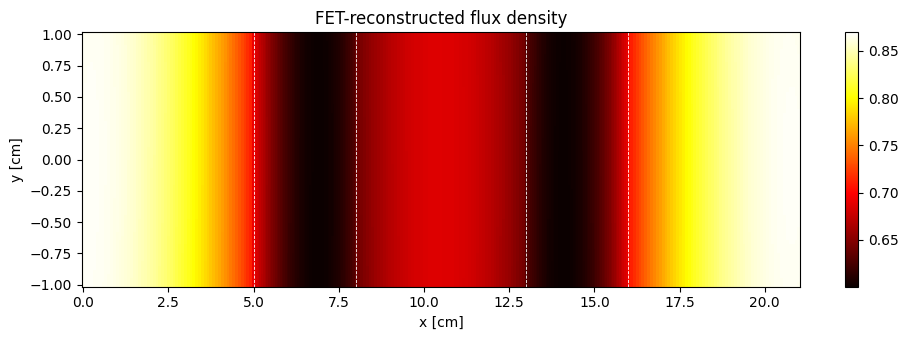

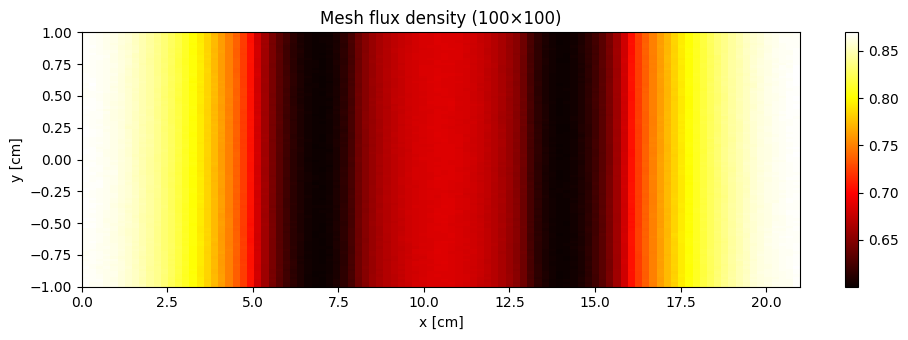

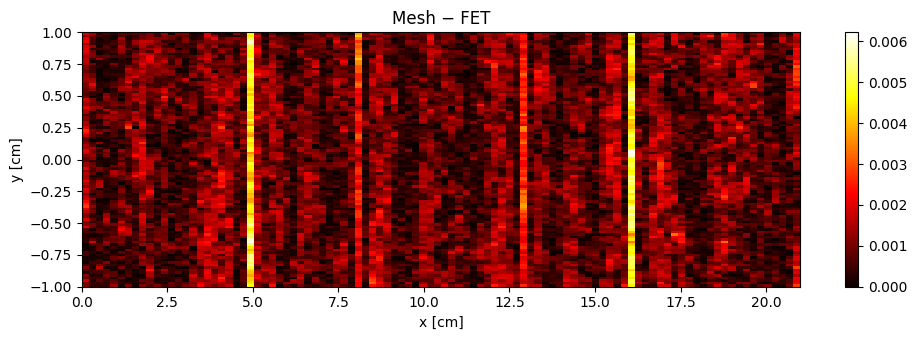

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import openmc
from numpy.polynomial.legendre import legval2d

SLAB_WIDTHS = [5.0, 3.0, 5.0, 3.0, 5.0]
Y_EXTENT    = (-1.0, 1.0)
Z_EXTENT    = (-1.0, 1.0)
ORDER_X     = ORDER_Y = order
STATEPOINT  = 'statepoint.300.h5'



def slab_edges(widths):
    """x-coordinates of slab boundaries, length len(widths)+1."""
    return np.concatenate(([0.0], np.cumsum(widths)))


def load_fet_coeffs(sp, n_slabs, order_x, order_y):
    """Return a list of (order_x, order_y) coefficient arrays, one per slab."""
    return [
        sp.get_tally(name=f'fet_slab{i}')
          .get_values(scores=['flux'], value='mean')
          .squeeze().reshape(order_x, order_y)
        for i in range(n_slabs)
    ]


def load_mesh_flux(sp, nx, ny):
    """Return the raw mesh flux tally reshaped to (nx, ny)."""
    return (sp.get_tally(name='mesh')
              .get_values(scores=['flux'], value='mean')
              .squeeze().reshape(nx, ny).T)


def legendre_norm(order_x, order_y):
    """(2n+1)(2m+1) normalization matrix for the FET reconstruction."""
    return np.outer(2*np.arange(order_x) + 1, 2*np.arange(order_y) + 1)


def slab_volume(width, y_extent, z_extent):
    return width * (y_extent[1] - y_extent[0]) * (z_extent[1] - z_extent[0])


def make_fet_evaluator(coeffs, x_edges, widths, y_extent, z_extent):
    """Return a function eval_fet(i, x_phys, y_phys) -> 2D flux density array."""
    norm = legendre_norm(*coeffs[0].shape)
    scaled = [ c * norm / slab_volume(w, y_extent, z_extent)for c, w in zip(coeffs, widths) ]

    def eval_fet(i, x_phys, y_phys):
        x_lo, x_hi = x_edges[i], x_edges[i + 1]
        xi_x = 2 * (x_phys - x_lo) / (x_hi - x_lo) - 1
        X, Y = np.meshgrid(xi_x, y_phys, indexing='ij')
        return legval2d(X, Y, scaled[i])

    return eval_fet


def reconstruct_fet_grid(eval_fet, x_edges, n_per_slab=60, n_y=60, y_extent=(-1, 1)):
    """Evaluate the FET on a dense grid spanning every slab."""
    n_slabs = len(x_edges) - 1
    y = np.linspace(y_extent[0], y_extent[1], n_y)
    x_segs, f_segs = [], []
    for i in range(n_slabs):
        x_seg = np.linspace(x_edges[i], x_edges[i + 1], n_per_slab,
                            endpoint=(i == n_slabs - 1))
        x_segs.append(x_seg)
        f_segs.append(eval_fet(i, x_seg, y))
    return np.concatenate(x_segs), y, np.concatenate(f_segs, axis=0)


def fet_on_mesh_centers(eval_fet, x_edges, mxc, myc):
    """Sample the FET reconstruction at mesh cell centers."""
    n_slabs = len(x_edges) - 1
    out = np.zeros((len(mxc), len(myc)))
    slab_of_xc = np.clip(np.searchsorted(x_edges[1:], mxc, side='right'), 0, n_slabs - 1)
    for s in range(n_slabs):
        mask = slab_of_xc == s
        if mask.any():
            out[mask, :] = eval_fet(s, mxc[mask], myc)
    return out


def mesh_edges_and_centers(x_total, nx, ny, y_extent):
    mx_edges = np.linspace(0, x_total, nx + 1)
    my_edges = np.linspace(y_extent[0], y_extent[1], ny + 1)
    mxc = 0.5 * (mx_edges[:-1] + mx_edges[1:])
    myc = 0.5 * (my_edges[:-1] + my_edges[1:])
    return mx_edges, my_edges, mxc, myc


def mesh_flux_to_density(mesh_flux, x_total, nx, ny, y_extent, z_extent):
    cell_vol = ((x_total / nx)* ((y_extent[1] - y_extent[0]) / ny)* (z_extent[1] - z_extent[0]))
    return mesh_flux / cell_vol


def plot_heatmap(x, y, data, *, title, cmap='hot', vmin=None, vmax=None,
                 slab_boundaries=None, cbar_label=None, savepath=None):
    fig, ax = plt.subplots(figsize=(10, 3.5))
    pcm = ax.pcolormesh(x, y, data.T, shading='auto',
                        cmap=cmap, vmin=vmin, vmax=vmax)
    if slab_boundaries is not None:
        for xb in slab_boundaries:
            ax.axvline(xb, color='white', lw=0.6, ls='--')
    ax.set(xlabel='x [cm]', ylabel='y [cm]', title=title)
    fig.colorbar(pcm, ax=ax, label=cbar_label)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    return fig, ax



def main():
    x_edges = slab_edges(SLAB_WIDTHS)
    x_total = x_edges[-1]
    n_slabs = len(SLAB_WIDTHS)

    with openmc.StatePoint(STATEPOINT) as sp:
        fet_coeffs = load_fet_coeffs(sp, n_slabs, ORDER_X, ORDER_Y)
        mesh_flux  = load_mesh_flux(sp, MESH_NX, MESH_NY)

    eval_fet = make_fet_evaluator(fet_coeffs, x_edges, SLAB_WIDTHS, Y_EXTENT, Z_EXTENT)

    x_fine, y_fine, flux_fine = reconstruct_fet_grid(eval_fet, x_edges, y_extent=Y_EXTENT)

    mx_edges, my_edges, mxc, myc = mesh_edges_and_centers(x_total, MESH_NX, MESH_NY, Y_EXTENT)
    mesh_density = mesh_flux_to_density(mesh_flux, x_total, MESH_NX, MESH_NY, Y_EXTENT, Z_EXTENT)

    vmin = min(mesh_density.min(), flux_fine.min())
    vmax = max(mesh_density.max(), flux_fine.max())

    plot_heatmap(x_fine, y_fine, flux_fine,
                 title='FET-reconstructed flux density',
                 vmin=vmin, vmax=vmax,
                 slab_boundaries=x_edges[1:-1],
                 savepath='fet.png')

    plot_heatmap(mx_edges, my_edges, mesh_density,
                 title=f'Mesh flux density ({MESH_NX}×{MESH_NY})',
                 vmin=vmin, vmax=vmax,
                 savepath='mesh.png')

    fet_on_mesh = fet_on_mesh_centers(eval_fet, x_edges, mxc, myc)
    diff = np.abs(mesh_density - fet_on_mesh)
    d = np.max(np.abs(diff))

    plot_heatmap(mx_edges, my_edges, diff,
                 title='Mesh − FET',
                 cmap='hot', vmin=0, vmax=d,
                 savepath='diff.png')

    plt.show()


main()